In [72]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [73]:
def integrate(f, xt, t, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    dyn: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt, t)
    k2 = dt * f(xt+k1/2., t + dt/2.)
    k3 = dt * f(xt+k2/2., t + dt/2.)
    k4 = dt * f(xt+k3, t + dt)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        t = tvec[i]
        xtraj[:,i]=integrate(f,x,t,dt)
        x = np.copy(xtraj[:,i])
    return xtraj, tvec

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_59194/646551329.py:2: SyntaxWarning: invalid escape sequence '\d'
  """
/tmp/ipykernel_59194/646551329.py:31: SyntaxWarning: invalid escape sequence '\d'
  """


In [74]:
t, G ,J_cap, N, tau_m, k_d = sym.symbols(r't, G, J_{cap}, N, \tau_m, K_d')
J_jaw = N * J_cap

# J_1 = 1/2 * m1 * r1**2
# J_2 = 1/2 * m2 * r2**2

th1 = sym.Function(r'\theta_1')(t)
th2 = sym.Function(r'\theta_2')(t)
q = sym.Matrix([th1, th2])
q_dot = q.diff(t)
q_ddot = q_dot.diff(t)

# Relationship between the two pulleys
print("The gear ratio relationship between the two pulleys:")
display(sym.Eq(q_dot[0] / q_dot[1], G))

print("The inertia ratio relationship between the two pulleys:")
display(sym.Eq(sym.Symbol('J_jaw'), J_jaw))

# Kinetic energy of the system
KE = 1/2 * J_cap * q_dot[0]**2 + 1/2 * J_jaw* q_dot[1]**2
# print("\nThe kinetic energy of the system:")
# display(sym.Eq(sym.Symbol('KE'),KE))

# Substitute the gear ratio into expression
q_dot[1] = q_dot[0] / G

# Kinetic energy of the system with gear ratio substituted
KE = 1/2 * J_cap * q_dot[0]**2 + 1/2 * J_jaw* q_dot[1]**2

print("The kinetic energy of the system with the gear and inertia ratio substituted:")
display(sym.Eq(sym.Symbol('KE'),KE))

# Ignoring potential energy for now
L = KE

dLdq = L.diff(q[0])
dLdq_dot = L.diff(q_dot[0])
d_dLdq_dot_dt = dLdq_dot.diff(t)

lhs = d_dLdq_dot_dt - dLdq
rhs = tau_m - k_d * q_dot[0]

print("\nThe equation of motion when driving the capstan:")
eqn = sym.Eq(lhs, rhs)
display(sym.simplify(sym.nsimplify(eqn)))
soln_cap = sym.solve(eqn, q_ddot[0])
print("\nThe solution for the acceleration of the capstan:")
display(soln_cap[0])

print("The solution for the acceleration of the jaw:")
soln2 = soln_cap[0] / G
display(soln2)

J_eq = sym.simplify((tau_m - k_d * q_dot[0]) / soln_cap[0])
print("Reflected inerta at the motor:")
display(sym.Eq(sym.Symbol('J_eq,cap'), J_eq))


The gear ratio relationship between the two pulleys:


Eq(Derivative(\theta_1(t), t)/Derivative(\theta_2(t), t), G)

The inertia ratio relationship between the two pulleys:


Eq(J_jaw, J_{cap}*N)

The kinetic energy of the system with the gear and inertia ratio substituted:


...

G**2*(-K_d*Derivative(\theta_1(t), t) + \tau_m)/(J_{cap}*(G**2 + N))

The solution for the acceleration of the jaw:


G*(-K_d*Derivative(\theta_1(t), t) + \tau_m)/(J_{cap}*(G**2 + N))

Reflected inerta at the motor:


Eq(J_eq,cap, J_{cap} + J_{cap}*N/G**2)

In [75]:
tau_jaw = sym.symbols(r'\tau_{jaw}')

q_j = sym.Matrix([th2, th1])
q_dot_j = q_j.diff(t)
q_ddot_j = q_dot_j.diff(t)
q_dot_j[1] = q_dot_j[0] * G

KE_j = 1/2 * J_jaw * q_dot_j[0]**2 + 1/2 * J_cap * q_dot_j[1]**2
L_j = KE_j 

dLdq_j = L_j.diff(q_j[0])
dLdq_dot_j = L_j.diff(q_dot_j[0])
d_dLdq_dot_dt_j = dLdq_dot_j.diff(t)

eqn_j = sym.Eq(d_dLdq_dot_dt_j - dLdq_j, tau_jaw - k_d * G**2 *q_dot_j[0])
print("The equation of motion when driving the jaw:")
display(sym.simplify(sym.nsimplify(eqn_j)))
soln_jaw = sym.solve(eqn_j, q_ddot_j[0])
print("The solution for the acceleration of the jaw:")
display(soln_jaw[0])

soln_jaw2 = soln_jaw[0] * G
print("The solution for the acceleration of the capstan:")
display(soln_jaw2)

J_eq_jaw = sym.simplify((tau_jaw - k_d * G**2 * q_dot_j[0]) / soln_jaw[0])
print("Reflected inerta at the jaw:")
display(sym.Eq(sym.Symbol('J_eq,jaw'), J_eq_jaw))

The equation of motion when driving the jaw:


Eq(J_{cap}*(G**2 + N)*Derivative(\theta_2(t), (t, 2)), -G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})

The solution for the acceleration of the jaw:


(-G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})/(J_{cap}*(G**2 + N))

The solution for the acceleration of the capstan:


G*(-G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})/(J_{cap}*(G**2 + N))

Reflected inerta at the jaw:


Eq(J_eq,jaw, J_{cap}*(G**2 + N))

In [76]:
# thetaddot1_num = sym.lambdify((J_cap, N, G, tau_m), soln_cap[0])
# thetaddot2_num = sym.lambdify((J_cap, N, G, tau_jaw), soln_jaw[0])

In [77]:
from sympy import (
    diff, Function, Heaviside, inverse_laplace_transform,
    laplace_correspondence, laplace_initial_conds,
    laplace_transform, solve, symbols)


s = symbols('s')
Theta2_s = sym.symbols('Theta2_s')
T_jaw_s = sym.symbols('T_jaw_s')

tau_jaw_func = sym.Function('tau_jaw')(t)
eqn_j_temp = eqn_j.subs(tau_jaw, tau_jaw_func)

# display(eqn_j)
display(eqn_j_temp)
lhs_laplace = laplace_transform(eqn_j_temp.lhs, t, s, noconds=True)
rhs_laplace = laplace_transform(eqn_j_temp.rhs, t, s, noconds=True)

# display(lhs_laplace)
# display(rhs_laplace)

eqn_j_laplace = sym.Eq(lhs_laplace, rhs_laplace)
display(eqn_j_laplace)

zero_ics = {
    th2.subs(t, 0): 0,
    th2.diff(t).subs(t, 0): 0
}

eqn_s_zero_ic = eqn_j_laplace.subs(zero_ics)
display(eqn_s_zero_ic)

eqn_s_clean = eqn_s_zero_ic.replace(sym.laplace_transform(th2, t, s, noconds=True), Theta2_s)
eqn_s_clean = eqn_s_clean.replace(sym.laplace_transform(tau_jaw_func, t, s, noconds=True), T_jaw_s)

H_s = sym.solve(eqn_s_clean, Theta2_s)[0] / T_jaw_s
print("The transfer function is:")
display(sym.simplify(H_s))

Eq(1.0*G**2*J_{cap}*Derivative(\theta_2(t), (t, 2)) + 1.0*J_{cap}*N*Derivative(\theta_2(t), (t, 2)), -G**2*K_d*Derivative(\theta_2(t), t) + tau_jaw(t))

Eq(1.0*G**2*J_{cap}*(s**2*LaplaceTransform(\theta_2(t), t, s) - s*\theta_2(0) - Subs(Derivative(\theta_2(t), t), t, 0)) + 1.0*J_{cap}*N*(s**2*LaplaceTransform(\theta_2(t), t, s) - s*\theta_2(0) - Subs(Derivative(\theta_2(t), t), t, 0)), -G**2*K_d*(s*LaplaceTransform(\theta_2(t), t, s) - \theta_2(0)) + LaplaceTransform(tau_jaw(t), t, s))

Eq(1.0*G**2*J_{cap}*s**2*LaplaceTransform(\theta_2(t), t, s) + 1.0*J_{cap}*N*s**2*LaplaceTransform(\theta_2(t), t, s), -G**2*K_d*s*LaplaceTransform(\theta_2(t), t, s) + LaplaceTransform(tau_jaw(t), t, s))

The transfer function is:


1/(s*(G**2*J_{cap}*s + G**2*K_d + J_{cap}*N*s))

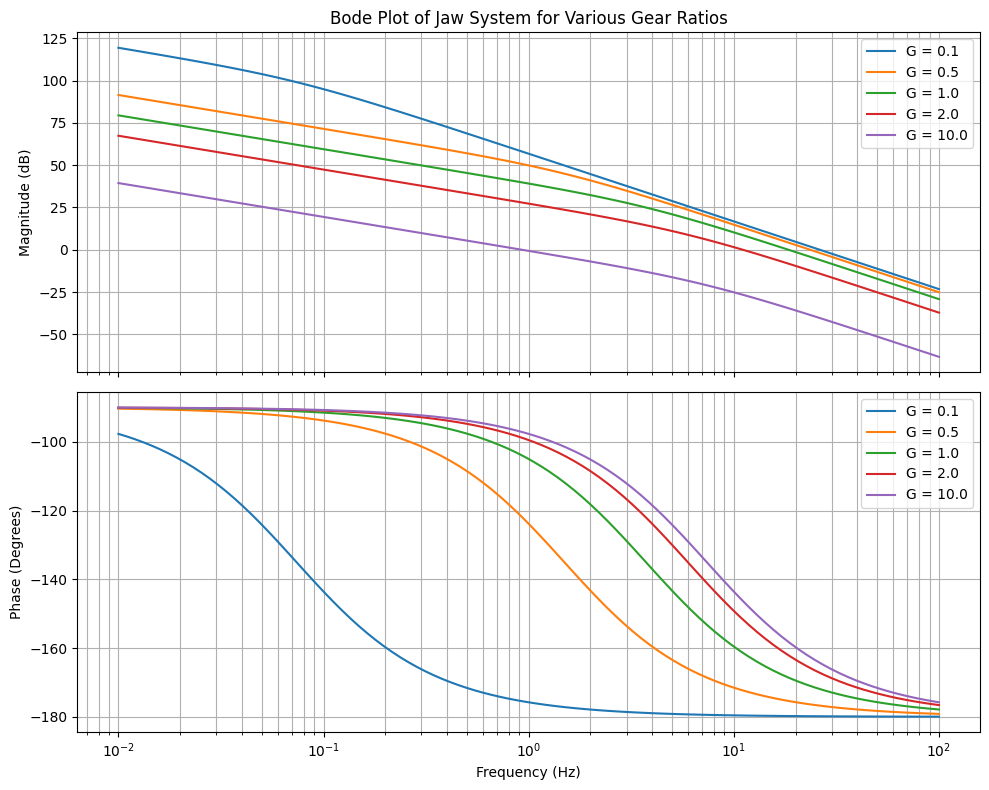

In [78]:
j_cap_val = 3.55e-5 + 8.199e-7
n_val = 1.0
kd_val = 0.0017

gear_ratios = [0.1, 0.5, 1.0, 2.0, 10.0]

freq_sweep = np.logspace(-2, 2, 100)
w_rad = freq_sweep * 2 * np.pi

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for g_val in gear_ratios:

    H_num = H_s.subs({J_cap: j_cap_val, N: n_val, k_d: kd_val, G: g_val})
    H_num = sym.simplify(H_num)

    num_sym, den_sym = sym.fraction(H_num)

    num_coeffs = [float(c) for c in sym.Poly(num_sym, s).all_coeffs()]
    den_coeffs = [float(c) for c in sym.Poly(den_sym, s).all_coeffs()]

    sys = signal.TransferFunction(num_coeffs, den_coeffs)

    w, mag, phase = signal.bode(sys, w=w_rad)


    ax_mag.semilogx(w / (2 * np.pi), mag, label=f'G = {g_val}') # X-axis back to Hz
    ax_phase.semilogx(w / (2 * np.pi), phase, label=f'G = {g_val}')

ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_title('Bode Plot of Jaw System for Various Gear Ratios')
ax_mag.grid(True, which="both", ls="-")
ax_mag.legend() # This displays the labels assigned during the loop

ax_phase.set_ylabel('Phase (Degrees)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.grid(True, which="both", ls="-")
ax_phase.legend()

plt.tight_layout()
plt.show()

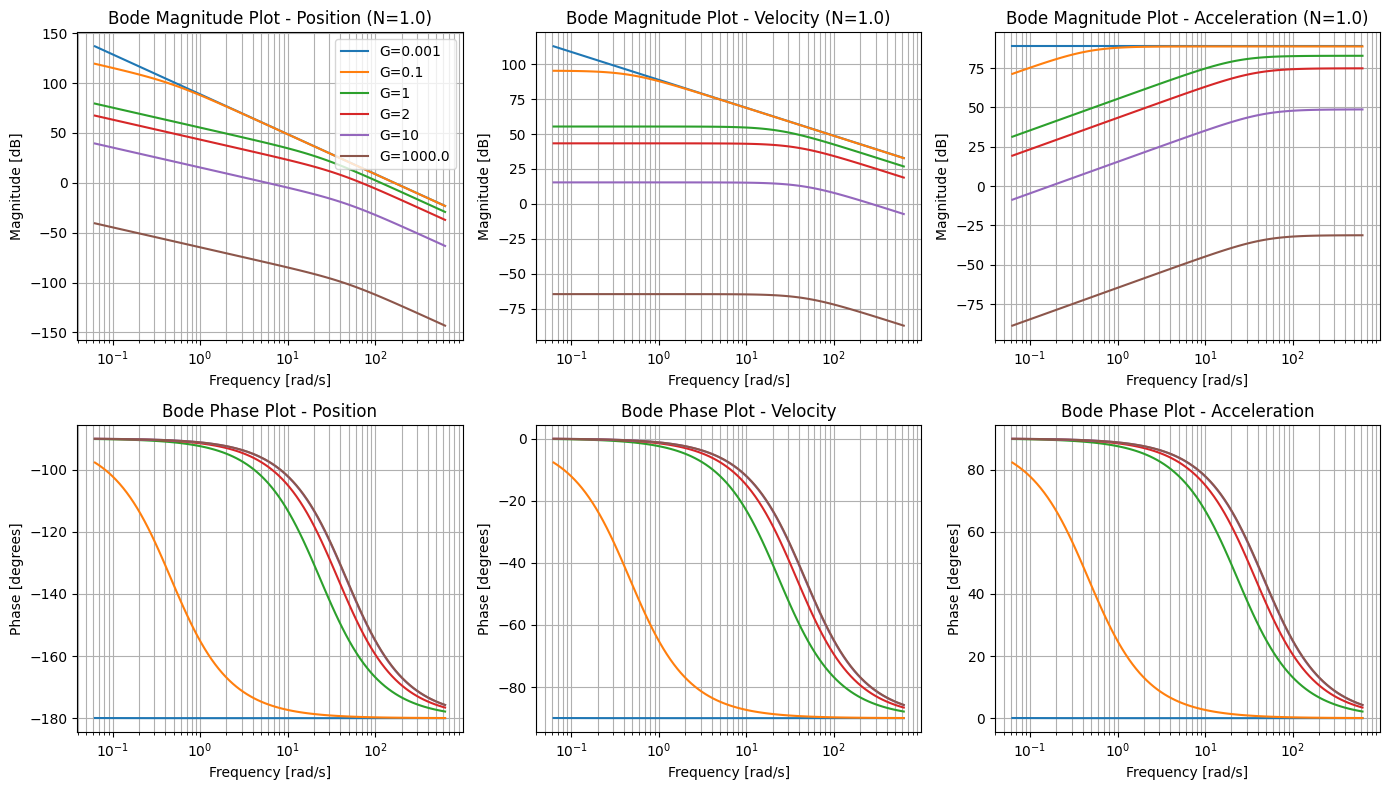

In [79]:

# System constants
J_cap = 3.55e-5 + 8.199e-7
N = 1.0  # Constant N of 1


# List of gear ratios to evaluate
G_values = [0.001, 0.1, 1, 2, 10, 1000.0]

# Setup frequency range
freq_hz = np.logspace(-2, 2, 100)
w = 2 * np.pi * freq_hz

# Setup plot
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
titles = ['Position', 'Velocity', 'Acceleration']

Kd = 0.0017

# Loop through each gear ratio
for G in G_values:
    # Calculate equivalent inertia for current G
    # J_eq = J_cap * (1 + N / G**2)  # This is for the motor
    J_eq = J_cap * (G**2 + N) # This is for the load side
    Kd_eq = Kd * G**2
    
    # Define transfer functions
    sys_pos = signal.TransferFunction([1], [J_eq, Kd_eq, 0])
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    sys_acc = signal.TransferFunction([1,0], [J_eq, Kd_eq])
    
    # Calculate Bode plots
    _, mag_pos, phase_pos = signal.bode(sys_pos, w)
    _, mag_vel, phase_vel = signal.bode(sys_vel, w)
    _, mag_acc, phase_acc = signal.bode(sys_acc, w)
    
    mags = [mag_pos, mag_vel, mag_acc]
    phases = [phase_pos, phase_vel, phase_acc]
    
    # Plot magnitudes and phases for this G
    for j in range(3):
        ax[0, j].semilogx(w, mags[j], label=f'G={G}')
        ax[1, j].semilogx(w, phases[j], label=f'G={G}')

# Formatting the plots (titles, labels, grids, legends)
for j in range(3):
    # Format Magnitude plots
    ax[0, j].set_title(f'Bode Magnitude Plot - {titles[j]} (N={N})')
    ax[0, j].set_xlabel('Frequency [rad/s]')
    ax[0, j].set_ylabel('Magnitude [dB]')
    ax[0, j].grid(True, which='both')
    if j == 0:
        ax[0, j].legend()  # Add legend to magnitude plots only for the first subplot
    
    # Format Phase plots
    ax[1, j].set_title(f'Bode Phase Plot - {titles[j]}')
    ax[1, j].set_xlabel('Frequency [rad/s]')
    ax[1, j].set_ylabel('Phase [degrees]')
    ax[1, j].grid(True, which='both')

fig.tight_layout()
plt.show()

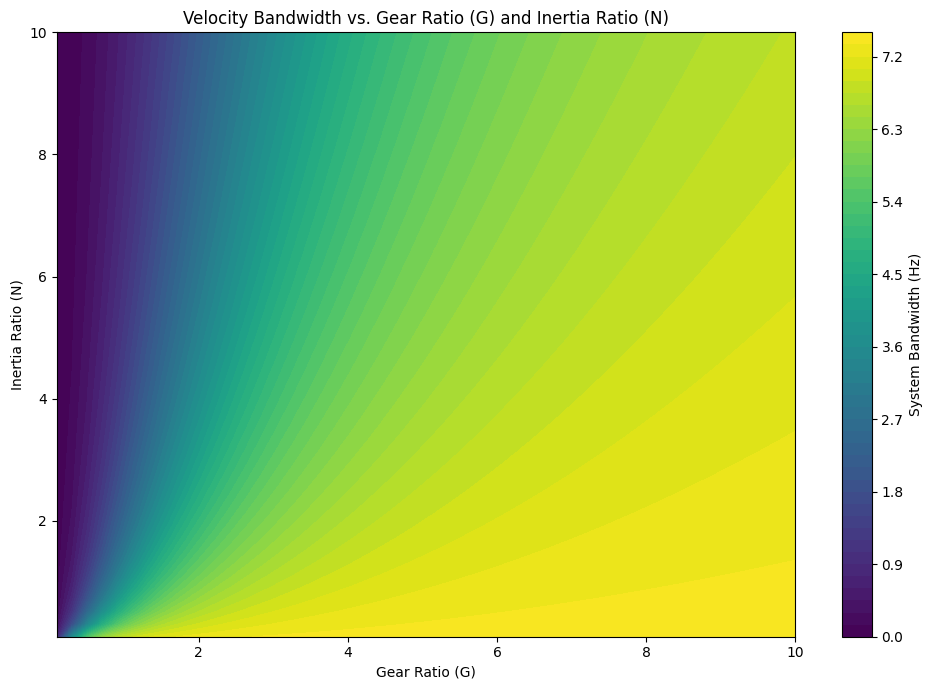

In [80]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def calculate_bandwidth(G, N, J_cap=3.63199e-5, Kd=0.0017):
    """
    Calculates the analytical -3dB bandwidth (in Hz) 
    for a given gear ratio (G) and inertia ratio (N).
    """
    J_eq = J_cap * (G**2 + N)
    Kd_eq = Kd * G**2
    
    # Velocity transfer function: H_vel(s) = 1 / (J_eq*s + Kd_eq)
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    
    # High-resolution frequency array (rad/s)
    w = np.logspace(-3, 4, 5000)
    w, mag, phase = signal.bode(sys_vel, w)
    
    # -3 dB threshold from DC gain (low-frequency reference)
    dc_gain_db = mag[0] 
    threshold_db = dc_gain_db - 3.0103
    
    # Interpolate to find the exact crossing frequency
    bandwidth_rads = np.interp(threshold_db, mag[::-1], w[::-1])
    bandwidth_hz = bandwidth_rads / (2 * np.pi)
    
    return bandwidth_hz

# 1. Define the ranges of G and N you want to evaluate
# Using more points (e.g., 50) creates a smoother heatmap
G_values = np.linspace(0.1, 10.0, 50) 
N_values = np.linspace(0.1, 10.0, 50)

# 2. Create a 2D matrix to store the results
bw_matrix = np.zeros((len(N_values), len(G_values)))

# 3. Loop through all combinations of G and N
for i, n in enumerate(N_values):
    for j, g in enumerate(G_values):
        bw_matrix[i, j] = calculate_bandwidth(g, n)

# 4. Generate the Contour Plot (Heatmap)
fig, ax = plt.subplots(figsize=(10, 7))

# Create meshgrid for plotting axes
G_grid, N_grid = np.meshgrid(G_values, N_values)

# Plot the surface
contour = ax.contourf(G_grid, N_grid, bw_matrix, levels=50, cmap='viridis')
cbar = fig.colorbar(contour)
cbar.set_label('System Bandwidth (Hz)')

# Formatting
ax.set_title('Velocity Bandwidth vs. Gear Ratio (G) and Inertia Ratio (N)')
ax.set_xlabel('Gear Ratio (G)')
ax.set_ylabel('Inertia Ratio (N)')

plt.tight_layout()
plt.show()

In [81]:
G_test, N_test = 2.0, 2.0
bw = calculate_bandwidth(G_test, N_test)
print(f"Bandwidth with G={G_test}, N={N_test}: {bw} rad/s")

Bandwidth with G=2.0, N=2.0: 4.966302334309676 rad/s


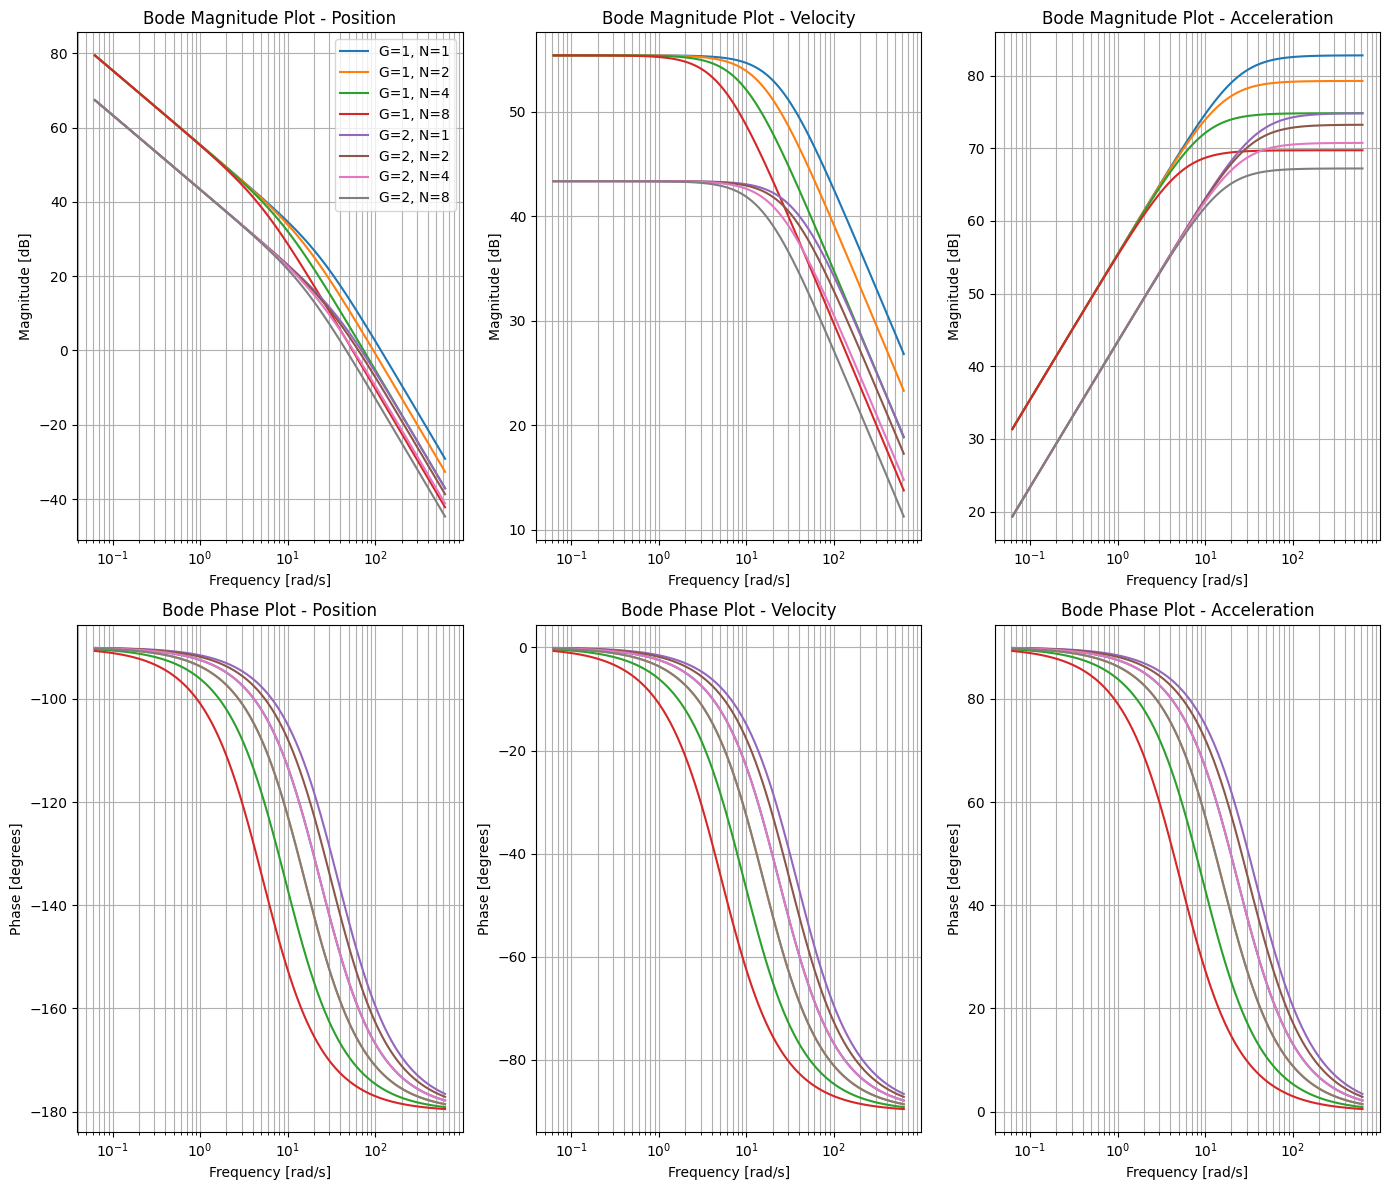

In [82]:
# Define the combinations of G and n values
# combos = [(0.5,0.25), (1, 1), (2, 4), (4, 16)]
# combos = [(0.1, 1), (0.1, 0.01), (0.1, 2), (0.1, 4), (0.1, 8), (1,1), (1,2), (1,4), (1,8), (2,1), (2,2), (2,4), (2,8), (4,1), (4,2), (4,4), (4,8), (4,16)]
combos = [(1,1), (1,2), (1,4), (1,8), (2,1), (2,2), (2,4), (2,8),]

fig, ax = plt.subplots(2, 3, figsize=(14, 12))


for Gv, nv in combos:
    # Calculate equivalent inertia for current G
    # J_eq = J_cap * (1 + nv / Gv**2)  # This is for the motor
    J_eq = J_cap * (Gv**2 + nv) # This is for the load side
    Kd_eq = 0.0017 * Gv**2
    # Define transfer functions
    sys_pos = signal.TransferFunction([1], [J_eq, Kd_eq, 0])
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    sys_acc = signal.TransferFunction([1,0], [J_eq, Kd_eq])
    
    # Calculate Bode plots
    _, mag_pos, phase_pos = signal.bode(sys_pos, w)
    _, mag_vel, phase_vel = signal.bode(sys_vel, w)
    _, mag_acc, phase_acc = signal.bode(sys_acc, w)
    
    mags = [mag_pos, mag_vel, mag_acc]
    phases = [phase_pos, phase_vel, phase_acc]
    
    # Plot magnitudes and phases for this G
    for j in range(3):
        ax[0, j].semilogx(w, mags[j], label=f'G={Gv}, N={nv}')
        ax[1, j].semilogx(w, phases[j], label=f'G={Gv}, N={nv}')

# Formatting the plots (titles, labels, grids, legends)
for j in range(3):
    # Format Magnitude plots
    ax[0, j].set_title(f'Bode Magnitude Plot - {titles[j]}')
    ax[0, j].set_xlabel('Frequency [rad/s]')
    ax[0, j].set_ylabel('Magnitude [dB]')
    ax[0, j].grid(True, which='both')
    if j == 0:
        ax[0, j].legend()  # Add legend to magnitude plots only for the first subplot
    
    # Format Phase plots
    ax[1, j].set_title(f'Bode Phase Plot - {titles[j]}')
    ax[1, j].set_xlabel('Frequency [rad/s]')
    ax[1, j].set_ylabel('Phase [degrees]')
    ax[1, j].grid(True, which='both')

fig.tight_layout()
plt.show()